In [1]:
%matplotlib inline
from wrapper import BasicEnvironmentRGB, DomainRandomization, RandomColorReplace
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation, ResizeObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP
from fvd_models import Encoder, Decoder, AEVAE
import numpy as np
import torch
import skdim
import ale_py
import os

np.random.seed(42)
torch.manual_seed(0)
# gym.utils.seeding.np_random(0)

to_numpy = lambda x: x.cpu().detach().numpy()
framestack = 2
latent_dim = 512
obs_shape = 64
data_steps = 200000
num_epochs = 50
steps_per_epoch = 1000
gym.register_envs(ale_py)
env = gym.make('ALE/Boxing-v5', render_mode="rgb_array")
env = BasicEnvironmentRGB(env)
env = ResizeObservation(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


In [2]:
obs, _ = env.reset()

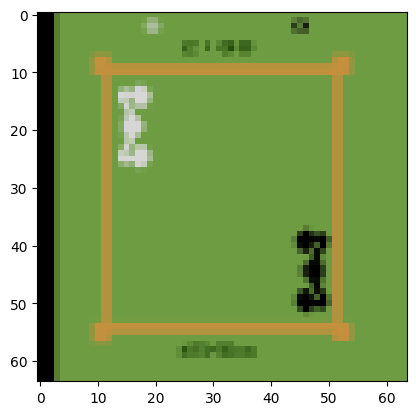

In [3]:
plt.imshow(obs[:, :, :3] / 255)

In [4]:
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)
filepath = "atari_buffer.npz"
if os.path.isfile(filepath):
  buffer.load(filepath)
else:
  samples = random_sample_single_env(env, num_steps=data_steps)
  for i in range(data_steps):
      buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())
  buffer.save(filepath=filepath)

In [5]:
encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.97)

In [6]:
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(steps_per_epoch):
        samples = buffer.sample(256)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        latent = encoder(obs)
        reconstruction = decoder(latent)
        loss = torch.nn.functional.mse_loss(reconstruction, obs)
        loss.backward()
        opt.step()
        opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    scheduler.step()
    if i % 10 == 0:
        print(i * steps_per_epoch)

KeyboardInterrupt: 

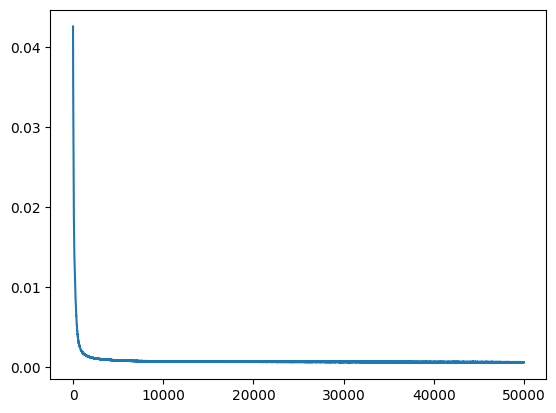

In [ ]:
plt.plot(losses)


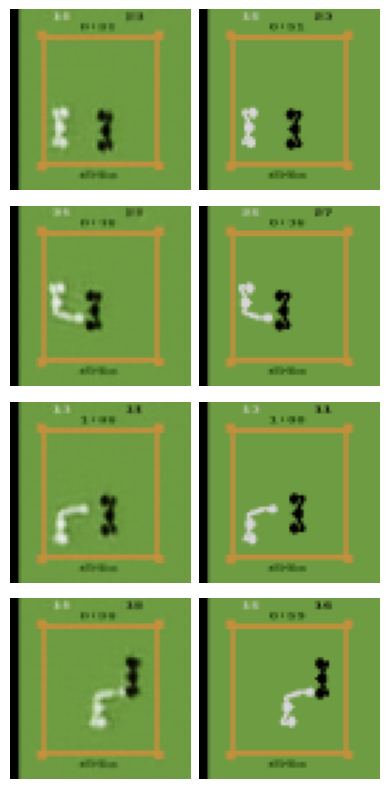

In [ ]:
num_img = 4
fig, axs = plt.subplots(nrows=num_img, ncols=2, figsize=(4, 2 * num_img))
for i in range(4):
    axs[i][0].imshow(reconstruction[i].detach().cpu().transpose(-3, -1).numpy()[:, :, :3])
    axs[i][0].axis("off")
    axs[i][1].imshow(samples[0][i][:, :, :3])
    axs[i][1].axis("off")
plt.tight_layout()
plt.show()
fig.savefig("direct_dim.png")

In [ ]:
latent_ID = []
image_ID = []

for _ in range(20):
    samples = buffer.sample(2048)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs)
    unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
    unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

    latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
    image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")


Latent ID: 13.764722120605239 +- 0.11352557875271901
Image ID: 13.561338843662616 +- 0.0844411900264677


In [ ]:
intrinsic_dim = round(np.mean(latent_ID))
penalty_coef = 1e-3
double_autoencoder = AEVAE(encoder, decoder, latent_dim, intrinsic_dim, penalty_coef=penalty_coef).cuda()
int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-4)
int_scheduler = torch.optim.lr_scheduler.ExponentialLR(int_opt, gamma=0.97)
penalty_anneal = np.linspace(0, 1, num_epochs) ** 0.25 * penalty_coef
losses = []
for i in range(1, num_epochs + 1):
    for _ in range(steps_per_epoch):
        samples = buffer.sample(256)
        obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
        loss = double_autoencoder.reconstruction_loss(obs, penalty_anneal[num_epochs-1])
        loss.backward()
        int_opt.step()
        int_opt.zero_grad()
        losses.append(loss.detach().cpu().numpy())
    int_scheduler.step()
    if i % 10 == 0:
        print(i * steps_per_epoch)
plt.plot(losses)

10000
20000
30000
40000
50000


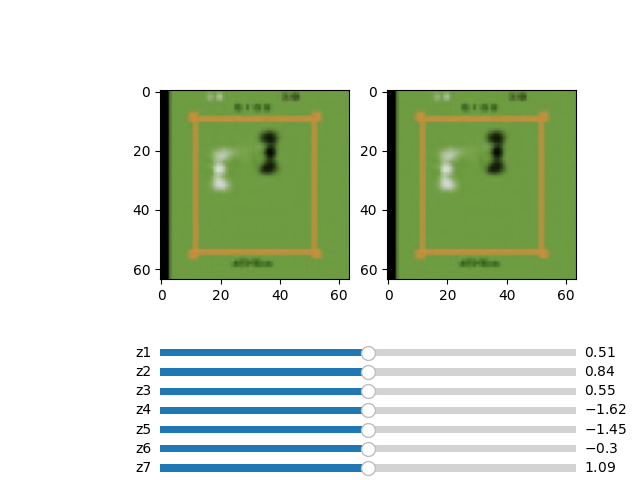

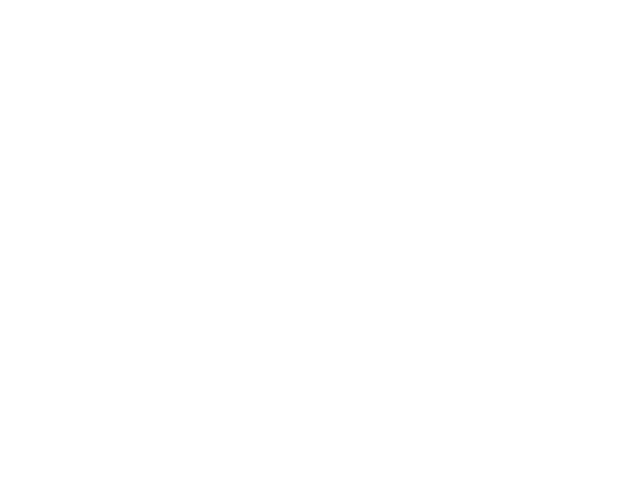

In [ ]:
plt.close("all")
from matplotlib.widgets import Slider
%matplotlib widget

def decode(intrinsic):
    intrinsic_tensor = torch.tensor(intrinsic).cuda()
    reconstruction = double_autoencoder.double_decode(intrinsic_tensor)
    reconstruction = to_numpy(reconstruction[0].transpose(-3, -1))
    return reconstruction[:, :, :3], reconstruction[:, :, 3:]

intrinsic = double_autoencoder.double_encode(obs)
intrinsic = to_numpy(intrinsic[0])

plt.figure()
img = decode(intrinsic)
f, axs = plt.subplots(1, 2)
img_handle1 = axs[0].imshow(img[0])
img_handle2 = axs[1].imshow(img[1])

plt.subplots_adjust(left=0.25, bottom=0.35)

slider_axes = []
sliders = []
for i in range(intrinsic_dim):
    ax = plt.axes([0.25, 0.25 - i*0.04, 0.65, 0.03])
    slider_axes.append(ax)
    slider = Slider(ax, f'z{i+1}', intrinsic[i]-20.0, intrinsic[i]+20.0, valinit=intrinsic[i])
    sliders.append(slider)

def update(val):
    for i, slider in enumerate(sliders):
        intrinsic[i] = slider.val
    img = decode(intrinsic)
    img_handle1.set_data(img[0])
    img_handle2.set_data(img[1])
    plt.draw()

for slider in sliders:
    slider.on_changed(update)

plt.show()

[19.937077 18.47952  18.06926  17.738401 16.644686 16.390663 16.0756
 15.980733 15.231293 14.743577 14.639358 13.651955 13.235795 12.104589]
[[-6.27664402e-02  1.26275256e-01  3.20412815e-01  2.49470621e-01
   1.73360288e-01 -2.32773155e-01 -1.81069434e-01 -2.44406685e-01
  -2.72799820e-01  5.47153413e-01 -3.33664030e-01  8.08101222e-02
  -2.97334820e-01  2.41641372e-01]
 [-2.33917177e-01  4.22477275e-01 -4.68145549e-01  5.61313629e-02
   4.14493293e-01  2.54478961e-01  2.76721567e-01 -3.86566669e-01
   7.02896044e-02  1.52093560e-01  1.15798973e-01  1.69873759e-01
   1.06579222e-01  1.46013694e-02]
 [ 1.51865244e-01 -9.84809995e-02  4.79844391e-01 -2.84761995e-01
   3.29710871e-01  2.21485555e-01 -1.82533026e-01 -9.38144922e-02
  -4.64106631e-03  2.38543406e-01  1.59920231e-01  1.83155298e-01
   5.33202112e-01 -2.35933319e-01]
 [ 3.50328863e-01  3.75593938e-02  3.97957340e-02 -3.58551681e-01
   1.10023417e-01 -1.93066359e-01  4.83635634e-01 -2.89687812e-02
   3.98463346e-02 -1.2633192

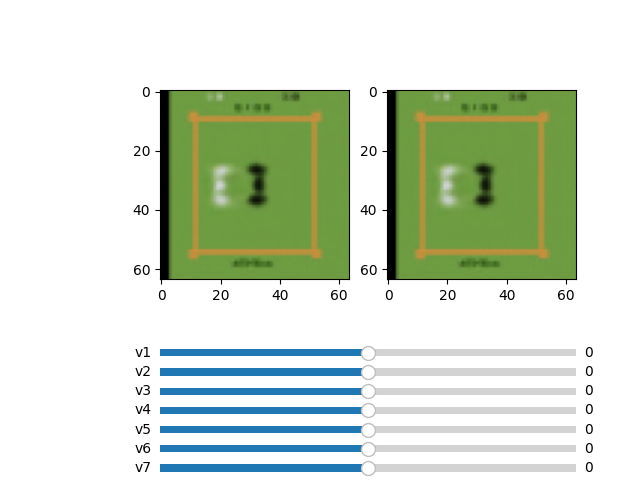

In [ ]:
plt.close("all")
intrinsic = double_autoencoder.double_encode(obs)
intrinsic_base = to_numpy(intrinsic[0])
intrinsic_base = np.zeros_like(intrinsic_base) # for VAE
u, s, v = np.linalg.svd(to_numpy(intrinsic), full_matrices=False)
print(s)
print(v)
f, axs = plt.subplots(1, 2)

img = decode(intrinsic_base)
img_handle1 = axs[0].imshow(img[0])
img_handle2 = axs[1].imshow(img[1])

plt.subplots_adjust(left=0.25, bottom=0.35)

slider_axes = []
sliders = []
for i in range(intrinsic_dim):
    ax = plt.axes([0.25, 0.25 - i*0.04, 0.65, 0.03])
    slider_axes.append(ax)
    slider = Slider(ax, f'v{i+1}', -10.0, +10.0, valinit=0.0)
    sliders.append(slider)

def update(val):
    intrinsic_temp = intrinsic_base.copy()
    for i, slider in enumerate(sliders):
        intrinsic_temp += slider.val * v[i]
    img = decode(intrinsic_temp)
    img_handle1.set_data(img[0])
    img_handle2.set_data(img[1])
    
    f.canvas.draw_idle()

for slider in sliders:
    slider.on_changed(update)

plt.show()